# Model Predictions and Visualization

This notebook loads trained convCNP models and visualizes predictions on holdout time periods.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Select one deterministic day from the holdout period
4. Generate predictions for all spatial points using configurable context input:
   - **ERA5_GRID**: Full or sparse ERA5-Local gridded data
   - **METEOSWISS**: Sparse MeteoSwiss observations placed on the ERA5 grid
   - Sparsity is controlled via `SPARSITY_TYPE` (PERCENT or ABSOLUTE) and the corresponding setting
5. Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Bias

After processing all folds, the holdout predictions are combined (since holdout periods are non-overlapping) to produce a single unified evaluation with error maps, uncertainty calibration, CRPS, and skill scores.

In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
MODEL_NAME = 'test-2023-30e-5f-smacnp-crps-2000sub-altcorrection'

# Number of target points per forward pass — reduce if GPU OOM, raise for speed
CHUNK_SIZE = 5000

In [3]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_crps.py:257: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z (F(z) - H(z - x))^2 dz
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:10: SyntaxWarning: invalid escape sequence '\i'
  The Brier score (BS) scores binary forecasts $k \in \{0, 1\}$,
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:102: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z BS(F(z), H(z - x)) dz


In [4]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [5]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

In [6]:
# Build plot output directory and filename prefix
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    return PLOT_DIR / f"{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots


## Load Training Configuration

In [7]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_MAX_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
METEO_SWISS_MAX_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH

print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_MAX_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_MAX_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: test-2023-30e-5f-smacnp-crps-2000sub-altcorrection
  Variable: tmax
  Data year start: 2023
  N folds: 5
  Model: 128 channels, 6 blocks
  ERA5 max temp: datasets/ERA5_Land/max_temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  MeteoSwiss: datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc
  Topography: datasets/topo_subset.zarr


## Load Data

In [8]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation, era5_times = ds.load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    include_seasonal_embeddings=params.SEASONAL_FEATURES,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")
print(f"Time coordinates: {len(era5_times)} dates from {era5_times[0]} to {era5_times[-1]}")

# Compute seasonal features from time coordinates if the model was trained with them
# SEASONAL_FEATURES=False should disable seasonal features everywhere.
# The model's use_seasonal_in_mlp flag (from SEASONAL_FEATURES_IN_MLP) independently
# controls whether the MLP actually uses these features.
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(era5_times, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (n_times, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled (model was trained without them)")

# Load high-resolution topography (DEM and TPI)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: datasets/ERA5_Land/max_temperature/*.nc


Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 grid points a

In [9]:
# Load MeteoSwiss targets with elevation and TPI
target_x, target_y, target_topo = ds.prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=params.DATA_YEAR_START,
    device=device,
)

# Convert to tensors
target_y_tensor = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"Target Y shape: {target_y_tensor.shape}")
print(f"Target topo shape: {target_topo.shape}")

# Get grid shape for reshaping predictions
grid_N, grid_E = ds.get_meteoswiss_grid_shape(METEO_SWISS_MAX_TEMP_GLOB)
print(f"MeteoSwiss grid shape: ({grid_N}, {grid_E})")

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [10]:
# SMACNP takes point-format inputs — flatten ERA5 grid into N context points
x_context, y_context = ds.build_smacnp_context(era5_data)
print(f"x_context: {x_context.shape}   # (T, N_era5_cells, 6)")
print(f"y_context: {y_context.shape}   # (T, N_era5_cells, 1)")

x_context: torch.Size([365, 1769, 6])   # (T, N_era5_cells, 6)
y_context: torch.Size([365, 1769, 1])   # (T, N_era5_cells, 1)


In [11]:
# Build (M, 4) static features once; append per-day seasonal features in the loop.
_dummy = seasonal_features[0:1] if seasonal_features is not None else torch.zeros(1, 2, device=device)
_x_one_day, _ = ds.build_smacnp_targets(target_x, target_y, target_topo, _dummy, device=device)
x_target_static = _x_one_day[0, :, :4].contiguous()  # (M, 4): lat, lon, alt_norm, mTPI_norm
M = x_target_static.shape[0]
del _x_one_day, _dummy
print(f"x_target_static: {x_target_static.shape}   # (M, 4)")

def make_x_target_day(day_idx: int) -> torch.Tensor:
    """Combine static spatial features with today's seasonal → (M, 6)."""
    if seasonal_features is not None:
        seas = seasonal_features[day_idx].unsqueeze(0).expand(M, -1)  # (M, 2)
        return torch.cat([x_target_static, seas], dim=-1)              # (M, 6)
    return x_target_static

x_target_static: torch.Size([88800, 4])   # (M, 4)


In [12]:
# Compute reference predictions: ERA5 bilinearly interpolated to target locations.
# This is a deterministic baseline representing "what ERA5 says at each station".
era5_ref_preds = ds.interpolate_era5_to_targets(era5_data, target_x, metadata)
era5_ref_denorm = metadata.denormalize(era5_ref_preds.cpu().numpy()) - 273.15
print(f"Reference predictions shape: {era5_ref_denorm.shape}  # (time, n_points)")

Reference predictions shape: (365, 88800)  # (time, n_points)


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Total time samples: 365
Number of folds: 5
ERA5 grid shape: (29, 61)
MeteoSwiss grid shape: (240, 370)

Fold 1/5
Built SMACNP with 308,995 trainable parameters
  Loaded model from epoch 24
  Holdout period: days 0 to 72 (73 days)
  Holdout date range: 2023-01-01T00:00:00.000000000 to 2023-03-14T00:00:00.000000000
  Selected day index for single-day plot: 36
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/fold0_prediction.png


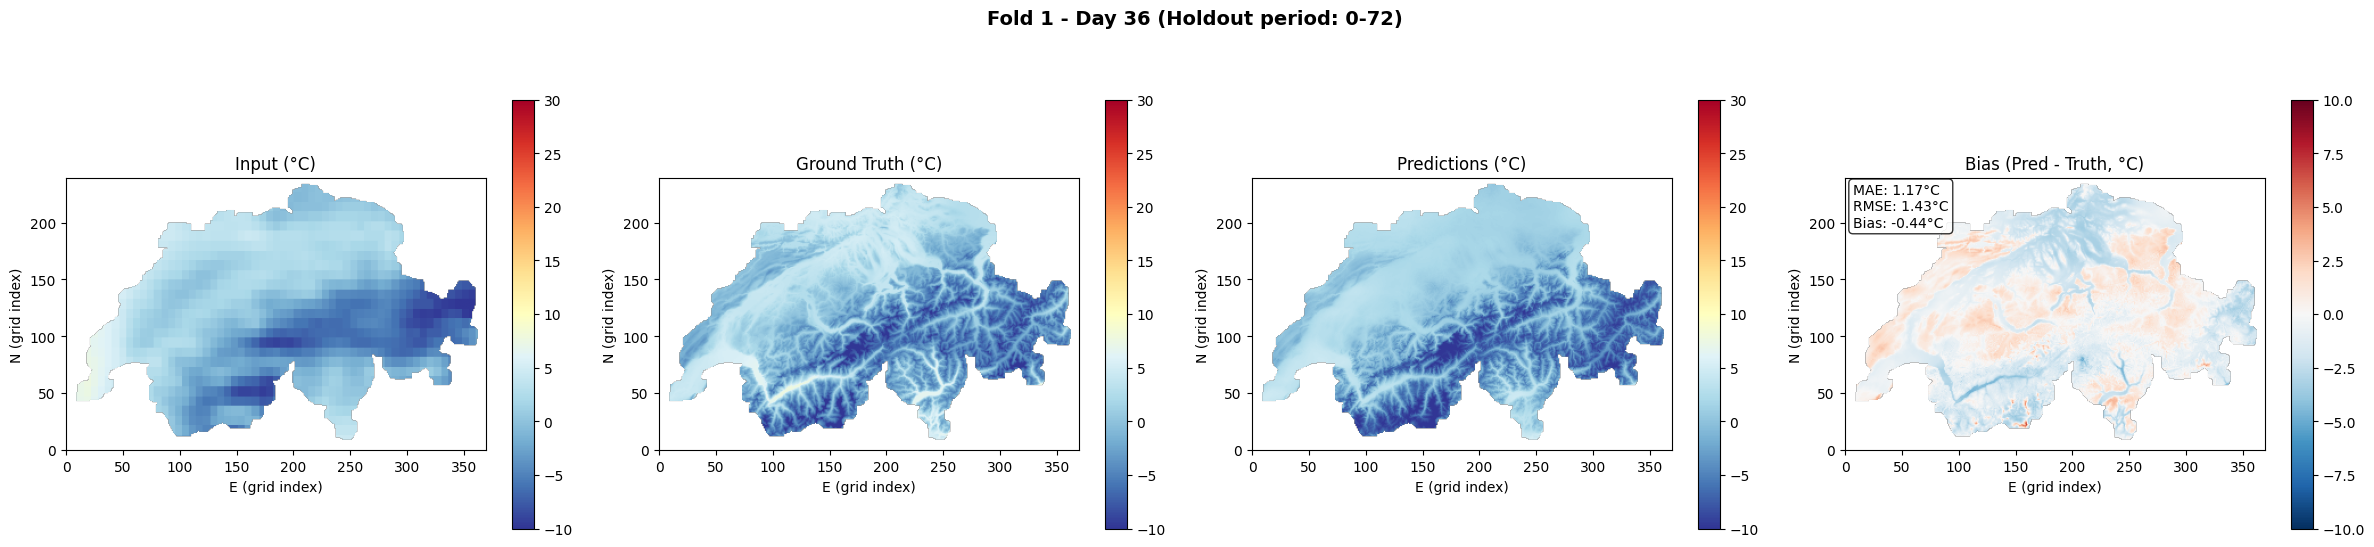

  Computing predictions for all 73 holdout days...
  Fold 1 done: accumulated 73 days

Fold 2/5
Built SMACNP with 308,995 trainable parameters
  Loaded model from epoch 28
  Holdout period: days 73 to 145 (73 days)
  Holdout date range: 2023-03-15T00:00:00.000000000 to 2023-05-26T00:00:00.000000000
  Selected day index for single-day plot: 109
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/fold1_prediction.png


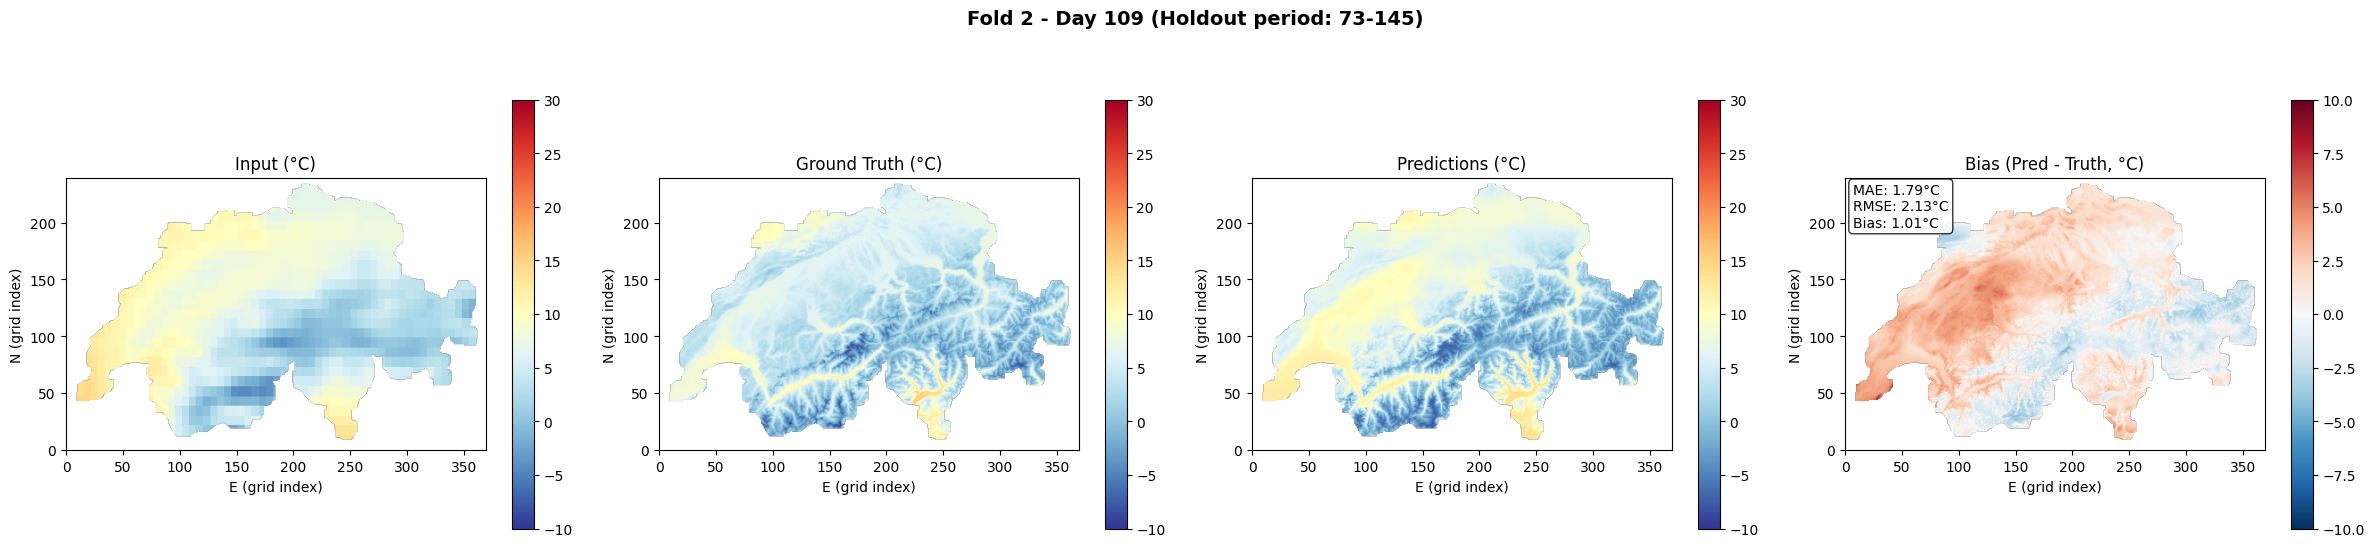

  Computing predictions for all 73 holdout days...
  Fold 2 done: accumulated 73 days

Fold 3/5
Built SMACNP with 308,995 trainable parameters
  Loaded model from epoch 28
  Holdout period: days 146 to 218 (73 days)
  Holdout date range: 2023-05-27T00:00:00.000000000 to 2023-08-07T00:00:00.000000000
  Selected day index for single-day plot: 182
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/fold2_prediction.png


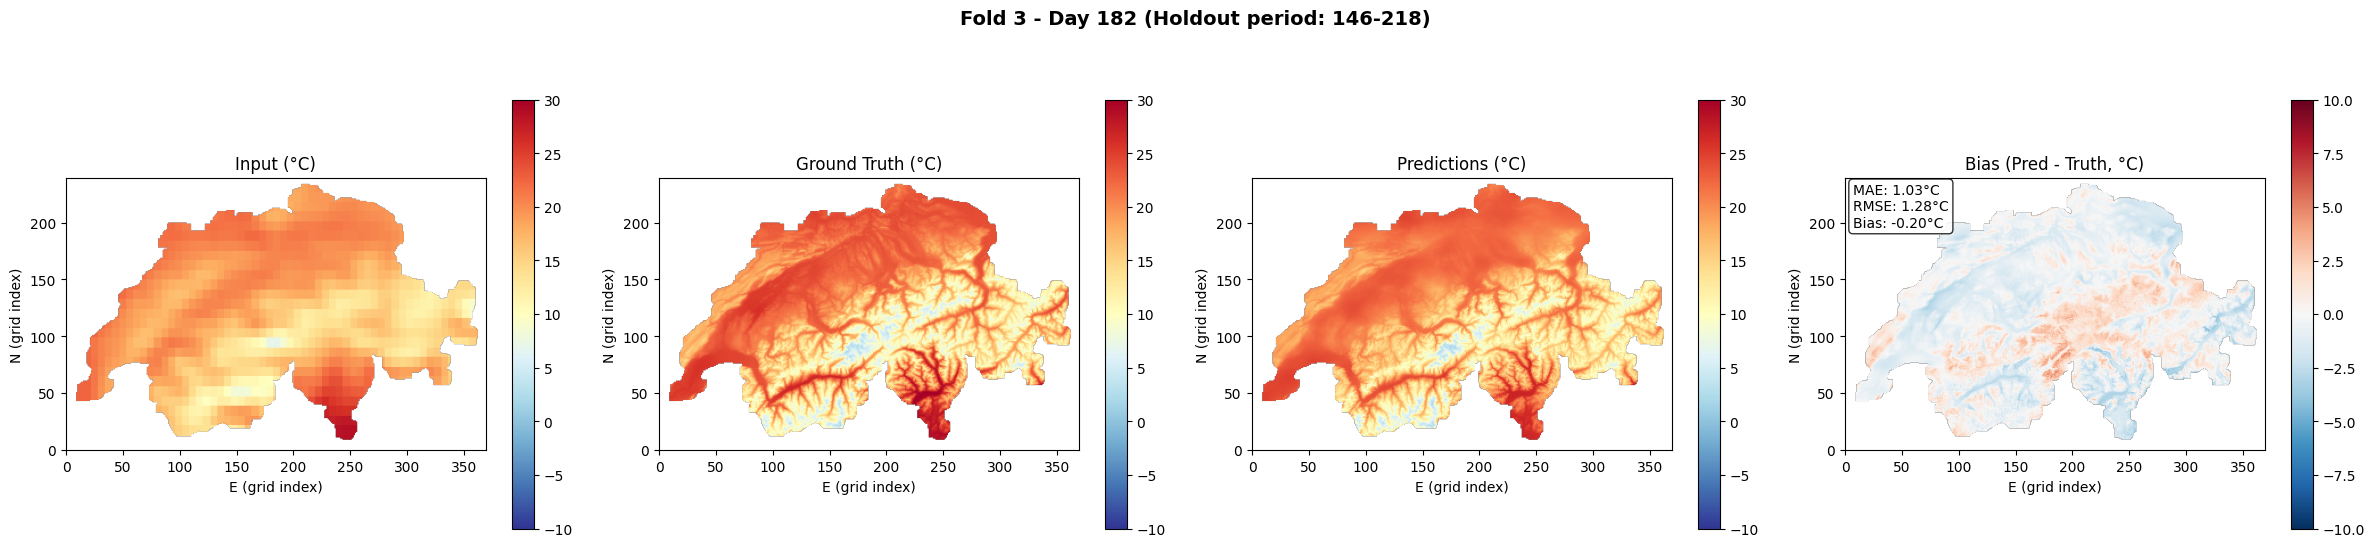

  Computing predictions for all 73 holdout days...
  Fold 3 done: accumulated 73 days

Fold 4/5
Built SMACNP with 308,995 trainable parameters
  Loaded model from epoch 26
  Holdout period: days 219 to 291 (73 days)
  Holdout date range: 2023-08-08T00:00:00.000000000 to 2023-10-19T00:00:00.000000000
  Selected day index for single-day plot: 255
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/fold3_prediction.png


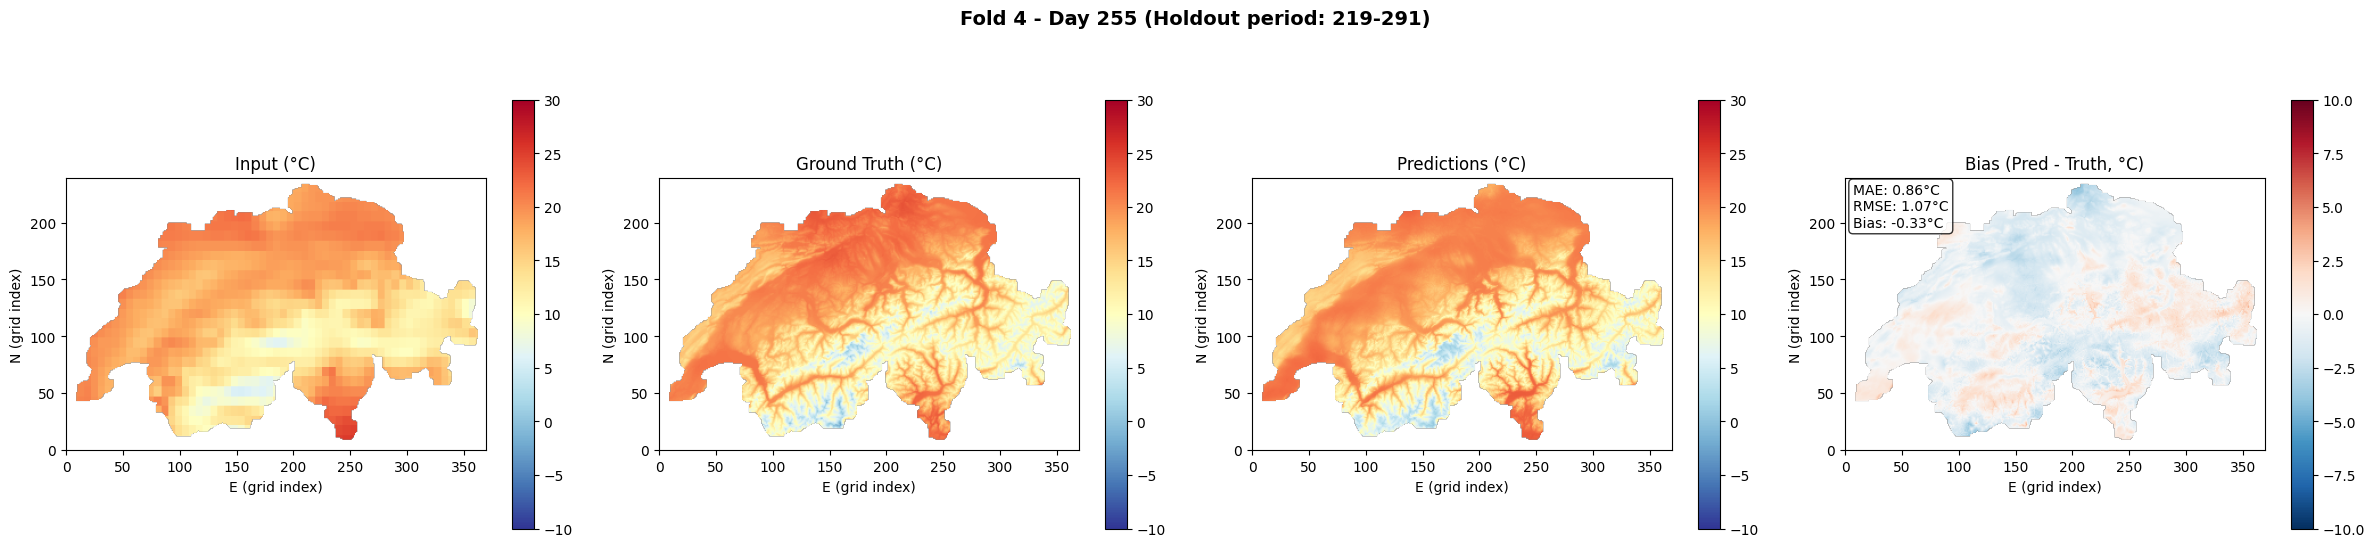

  Computing predictions for all 73 holdout days...
  Fold 4 done: accumulated 73 days

Fold 5/5
Built SMACNP with 308,995 trainable parameters
  Loaded model from epoch 9
  Holdout period: days 292 to 364 (73 days)
  Holdout date range: 2023-10-20T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
  Selected day index for single-day plot: 328
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/fold4_prediction.png


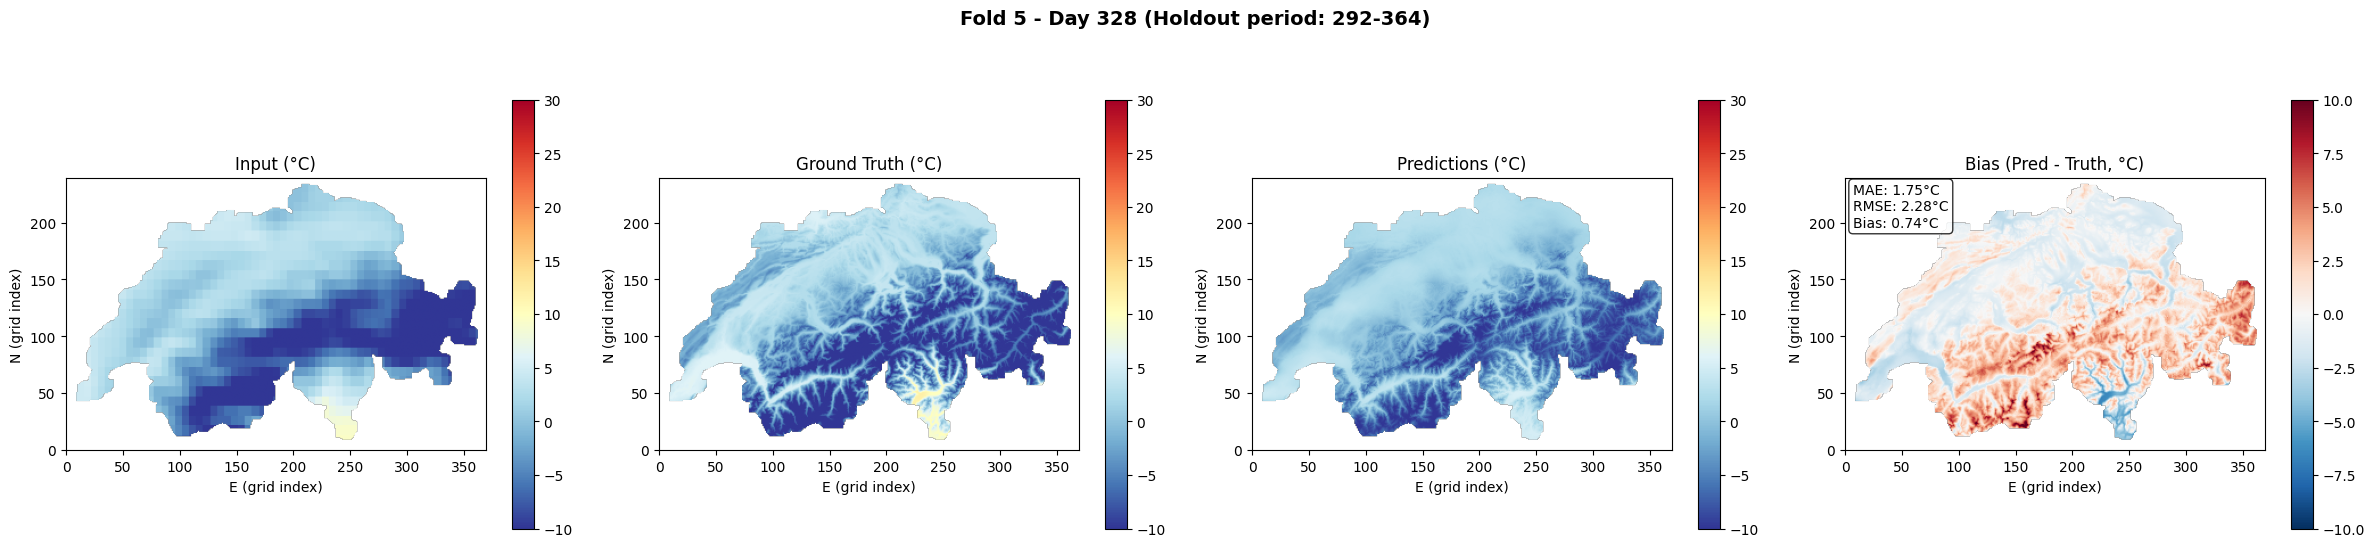

  Computing predictions for all 73 holdout days...
  Fold 5 done: accumulated 73 days

Combined holdout data: 365 days x 88800 points


In [13]:
era5_shape = (era5_data.shape[2], era5_data.shape[3])
n_samples = era5_data.shape[0]
grid_shape = (grid_N, grid_E)
N, E = grid_shape

print(f"Total time samples: {n_samples}")
print(f"Number of folds: {params.N_FOLDS}")
print(f"ERA5 grid shape: {era5_shape}")
print(f"MeteoSwiss grid shape: {grid_shape}")
print()

# Extract elevation and mTPI grids (these are static, same for all folds)
elev_np = target_topo.cpu().numpy()
true_elev_grid = elev_np[:, 0].reshape(N, E)  # True elevation in meters
mtpi_grid = elev_np[:, 2].reshape(N, E)  # mTPI in meters

# Accumulators for combined holdout analysis
combined_errors = []       # List of (holdout_days_i, n_points) arrays
combined_preds = []        # Denormalized predictions (°C)
combined_sigmas = []       # Predicted sigma
combined_truths = []       # Denormalized ground truth (°C)
combined_dates = []        # Holdout dates for temporal analysis
combined_ref_preds = []    # ERA5 reference predictions for skill score

for fold in range(params.N_FOLDS):
    print(f"={'=' * 59}")
    print(f"Fold {fold + 1}/{params.N_FOLDS}")
    print(f"={'=' * 59}")
    
    # Load model checkpoint
    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue
    
    model, epoch = model_factory.load_model_checkpoint(checkpoint_path, params, device,input_dim=x_context.shape[-1])
    print(f"  Loaded model from epoch {epoch}")
    
    # Get holdout period for this fold
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    holdout_days = holdout_end - holdout_start
    holdout_dates = era5_times[holdout_start:holdout_end]
    print(f"  Holdout period: days {holdout_start} to {holdout_end-1} ({holdout_days} days)")
    print(f"  Holdout date range: {holdout_dates[0]} to {holdout_dates[-1]}")
    
    # Select one day from holdout for the single-day visualization
    day_idx = select_holdout_day(fold, holdout_start, holdout_end, seed=params.SEED)
    print(f"  Selected day index for single-day plot: {day_idx}")
    
    # Generate predictions for single day visualization
    x_target_day = make_x_target_day(day_idx)
    predictions, sigma = inf.predict_single_day_smacnp(
        model, x_context, y_context, x_target_day, day_idx, device, CHUNK_SIZE
    )
    predictions_np = predictions.cpu().numpy()
    
    # Get ground truth and ERA5 input for single-day plot
    # Use context_data (not era5_data) so that sparse samples show only observed cells
    truth = target_y_tensor[day_idx].cpu().numpy()
    era5_temp = era5_data[day_idx, 0].cpu().numpy()
    
    # Plot single-day comparison (kept per fold)
    title = f"Fold {fold + 1} - Day {day_idx} (Holdout period: {holdout_start}-{holdout_end-1})"
    fig = vis.plot_prediction_comparison(
        truth=truth,
        predictions=predictions_np,
        era5_input=era5_temp,
        grid_shape=grid_shape,
        era5_shape=era5_shape,
        metadata=metadata,
        title=title,
        denormalize=True,
        save_path=plot_path(f"fold{fold}_prediction"),
    )
    plt.show()
    
    # Compute predictions for all holdout days and accumulate
    print(f"  Computing predictions for all {holdout_days} holdout days...")
    
    
    fold_errors, fold_preds, fold_sigmas, fold_truths = [], [], [], []
    for hi in range(holdout_start, holdout_end):
        x_target_hi = make_x_target_day(hi)
        preds_day, sigmas_day = inf.predict_single_day_smacnp(
            model, x_context, y_context, x_target_hi, hi, device, CHUNK_SIZE
        )
        preds_denorm = metadata.denormalize(preds_day.cpu().numpy()) - ds.KELVIN_OFFSET
        truth_denorm = metadata.denormalize(target_y_tensor[hi].cpu().numpy()) - ds.KELVIN_OFFSET
        fold_errors.append(preds_denorm - truth_denorm)
        fold_preds.append(preds_denorm)
        fold_sigmas.append(sigmas_day.cpu().numpy())
        fold_truths.append(truth_denorm)

    combined_errors.append(np.stack(fold_errors))
    combined_preds.append(np.stack(fold_preds))
    combined_sigmas.append(np.stack(fold_sigmas))
    combined_truths.append(np.stack(fold_truths))
    combined_dates.append(holdout_dates)
    combined_ref_preds.append(era5_ref_denorm[holdout_start:holdout_end])
    
    print(f"  Fold {fold + 1} done: accumulated {holdout_days} days")
    print()

# Concatenate all folds along time axis
all_errors = np.concatenate(combined_errors, axis=0)
all_preds_denorm = np.concatenate(combined_preds, axis=0)
all_sigmas = np.concatenate(combined_sigmas, axis=0)
all_truths_denorm = np.concatenate(combined_truths, axis=0)
all_holdout_dates = np.concatenate(combined_dates, axis=0)
all_ref_preds = np.concatenate(combined_ref_preds, axis=0)

print(f"Combined holdout data: {all_errors.shape[0]} days x {all_errors.shape[1]} points")

## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Computing combined metrics over 365 holdout days from 5 folds


Overall CRPS (°C): 1.273
Global skill score: 0.495
Overall MAE (°C): 1.366
Overall RMSE (°C): 1.773
Overall Bias (°C): -0.021
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/error_maps.png


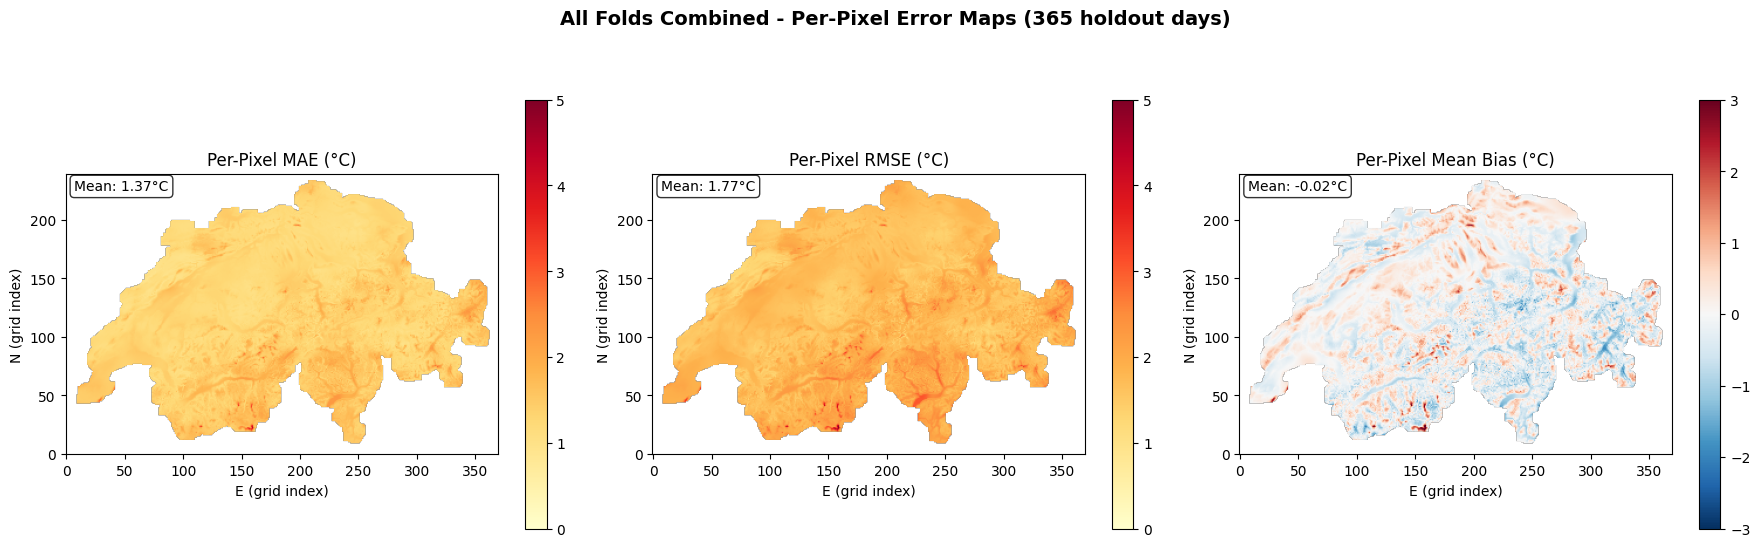

  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/uncertainty_vs_error.png


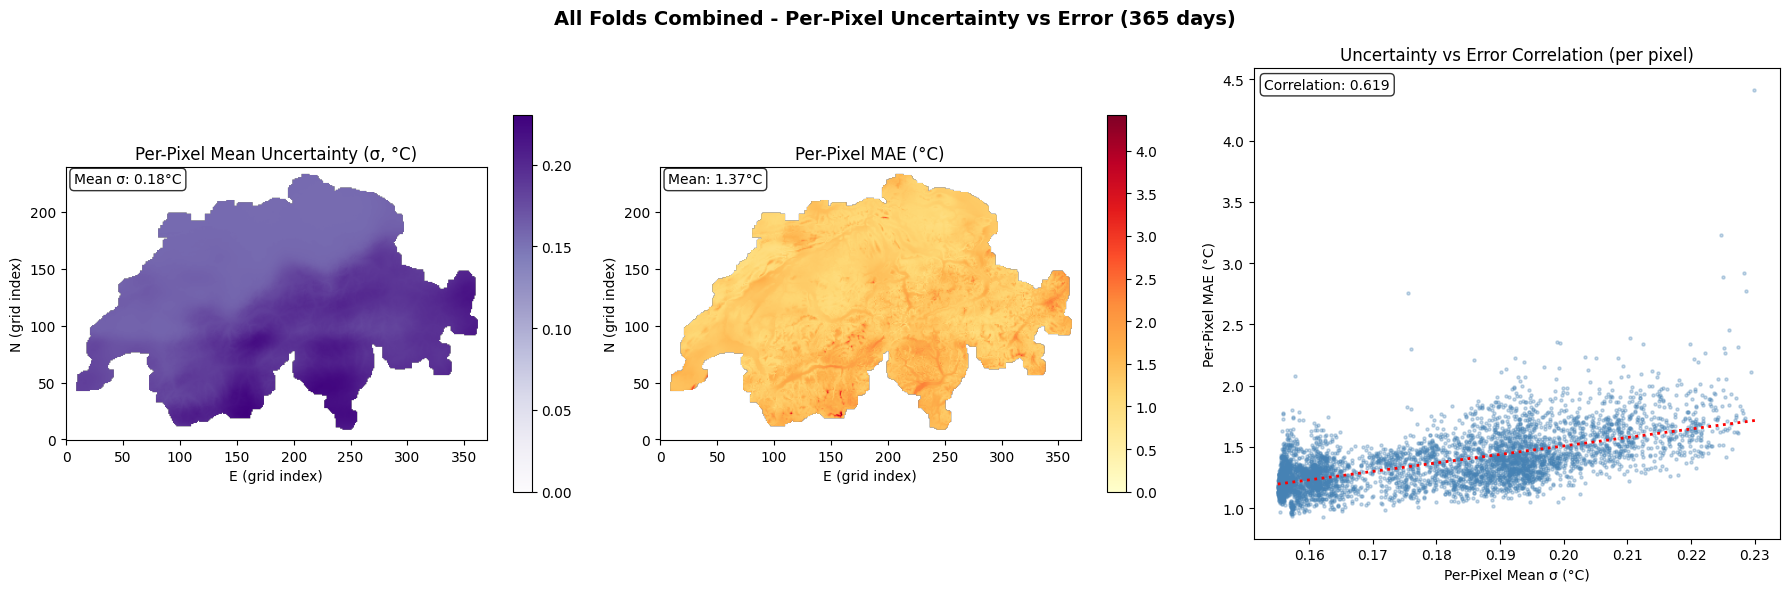

Per-pixel uncertainty-error correlation: 0.619
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/altitude_vs_error.png


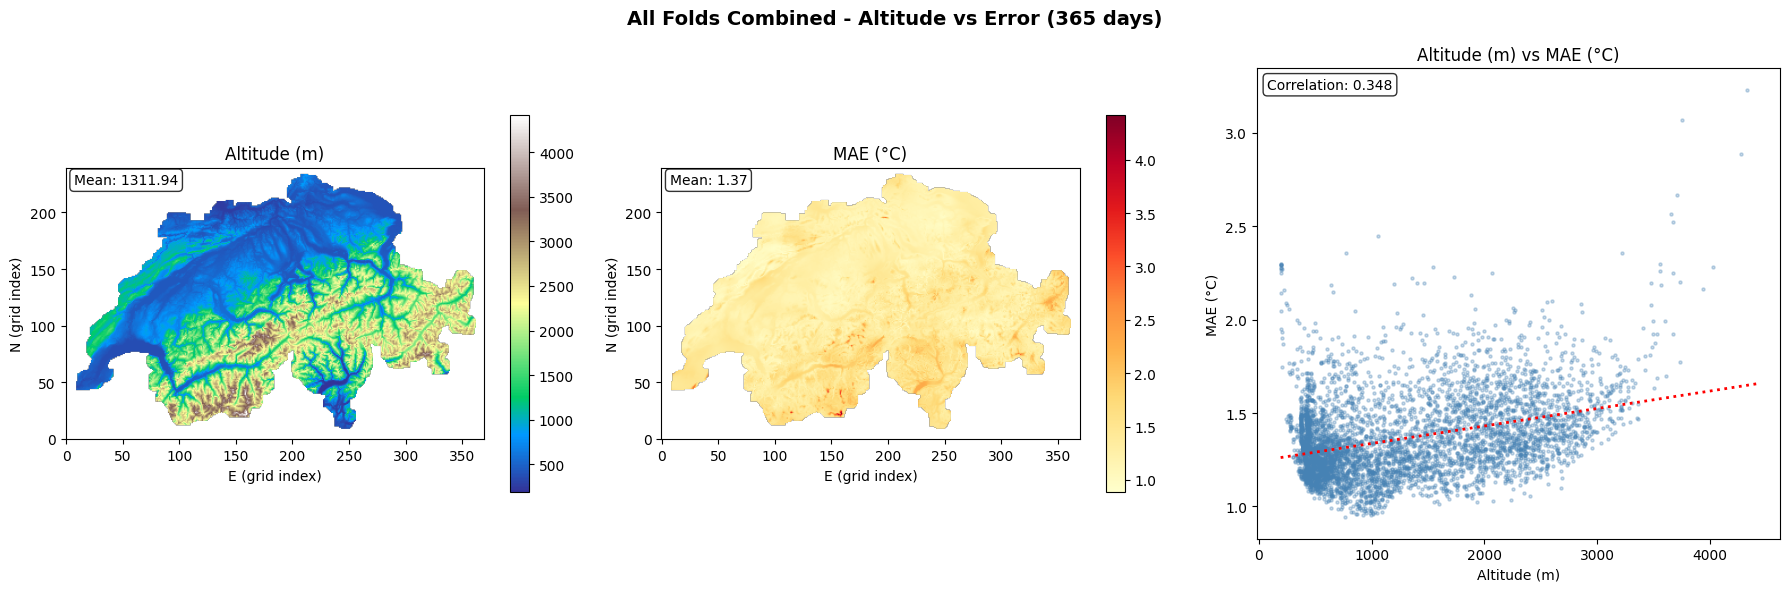

Altitude-error correlation: 0.348
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/mtpi_vs_error.png


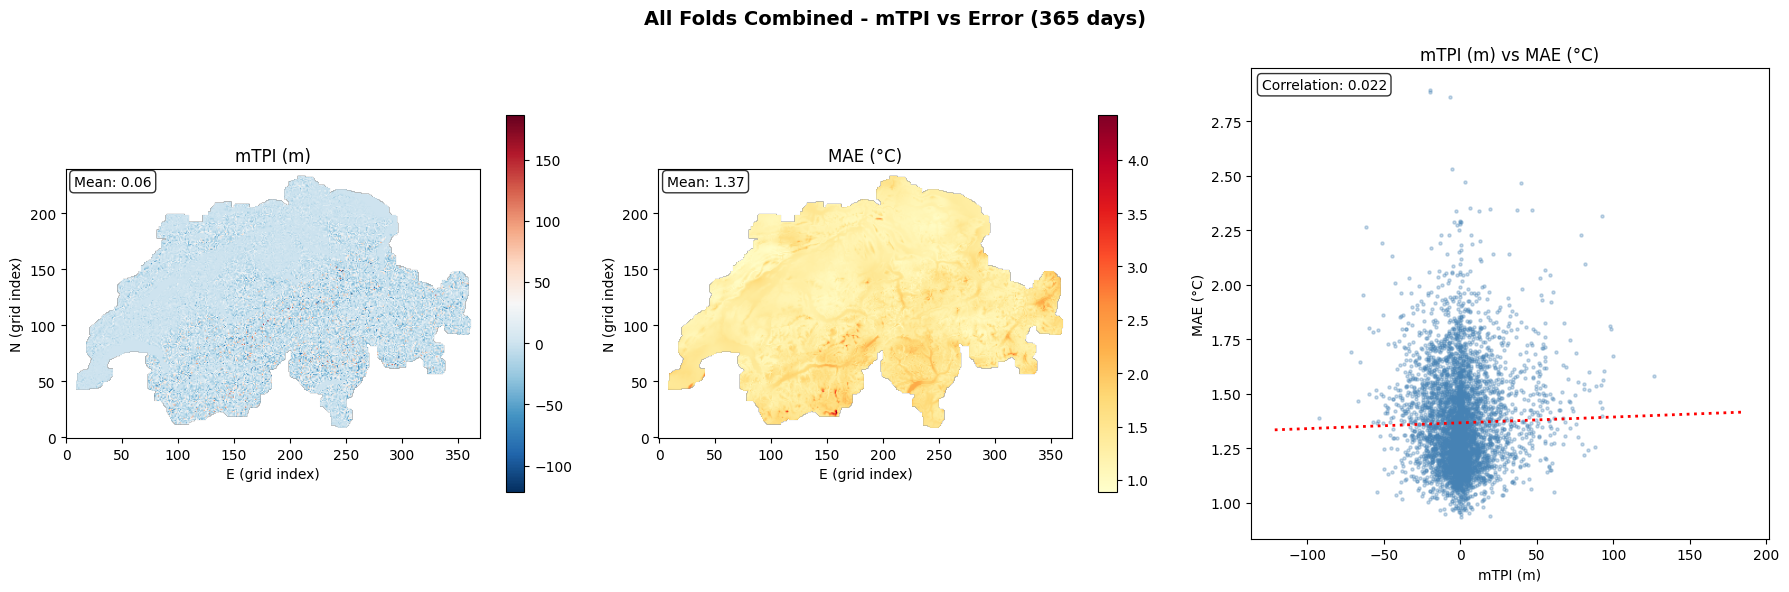

mTPI-error correlation: 0.022
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/doy_vs_error.png


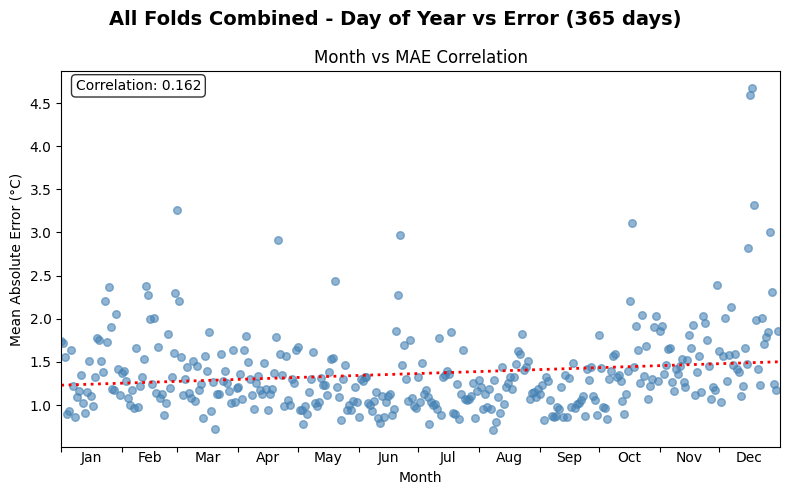

Day of year-error correlation: 0.162
  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/crps_map.png


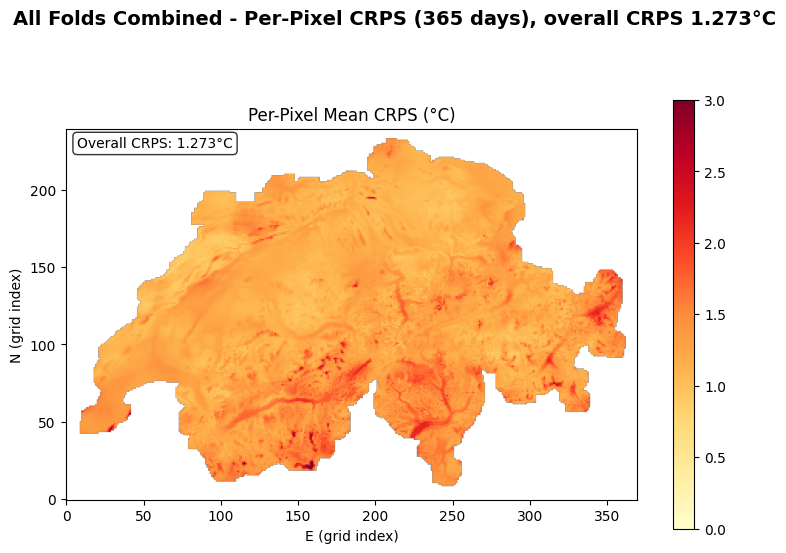

  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/skill_map.png


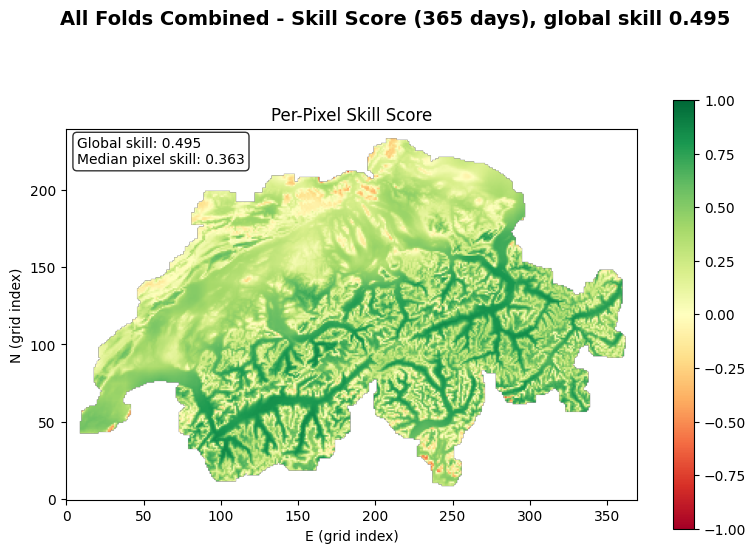

In [14]:
# --- Per-pixel metrics across all folds ---
total_days = all_errors.shape[0]
print(f"Computing combined metrics over {total_days} holdout days from {params.N_FOLDS} folds")

# Compute valid mask from first time step
sample_truth = target_y_tensor[0].cpu().numpy().reshape(N, E)
valid_mask = ~np.isnan(sample_truth)

m = metrics.compute_perpixel_metrics(
    all_errors=all_errors,
    all_preds=all_preds_denorm,
    all_sigmas=all_sigmas,
    all_truths=all_truths_denorm,
    all_ref_preds=all_ref_preds,
    grid_shape=(N, E),
    valid_mask=valid_mask,
)

print(f"Overall CRPS (°C): {m.overall_crps:.3f}")
print(f"Global skill score: {m.global_skill:.3f}")
print(f"Overall MAE (°C): {np.nanmean(m.mae_grid):.3f}")
print(f"Overall RMSE (°C): {np.nanmean(m.rmse_grid):.3f}")
print(f"Overall Bias (°C): {np.nanmean(m.bias_grid):.3f}")

# Mask topography grids for correlation plots
true_elev_grid_masked = np.where(valid_mask, true_elev_grid, np.nan)
mtpi_grid_masked = np.where(valid_mask, mtpi_grid, np.nan)

# --- Plots ---

# 1. Error maps
fig_errors = vis.plot_error_maps(
    mae_grid=m.mae_grid, rmse_grid=m.rmse_grid, bias_grid=m.bias_grid,
    title=f"All Folds Combined - Per-Pixel Error Maps ({total_days} holdout days)",
    error_range=(0, 5), bias_range=(-3, 3),
    save_path=plot_path("error_maps"),
)
plt.show()

# 2. Per-pixel uncertainty vs error
fig_unc, perpixel_corr = vis.plot_perpixel_uncertainty_vs_error(
    mean_sigma_grid=m.mean_sigma_grid, mae_grid=m.mae_grid,
    title=f"All Folds Combined - Per-Pixel Uncertainty vs Error ({total_days} days)",
    sigma_range=(0, np.nanmax(m.mean_sigma_grid)),
    error_range=(0, np.nanmax(m.mae_grid)),
    save_path=plot_path("uncertainty_vs_error"),
)
plt.show()
print(f"Per-pixel uncertainty-error correlation: {perpixel_corr:.3f}")

# 3. Altitude vs error
fig_alt, alt_corr = vis.plot_perpixel_correlation(
    x_grid=true_elev_grid_masked, y_grid=m.mae_grid,
    x_label='Altitude (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - Altitude vs Error ({total_days} days)",
    x_cmap='terrain', y_cmap='YlOrRd',
    save_path=plot_path("altitude_vs_error"),
)
plt.show()
print(f"Altitude-error correlation: {alt_corr:.3f}")

# 4. mTPI vs error
fig_mtpi, mtpi_corr = vis.plot_perpixel_correlation(
    x_grid=mtpi_grid_masked, y_grid=m.mae_grid,
    x_label='mTPI (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - mTPI vs Error ({total_days} days)",
    x_cmap='RdBu_r', y_cmap='YlOrRd',
    save_path=plot_path("mtpi_vs_error"),
)
plt.show()
print(f"mTPI-error correlation: {mtpi_corr:.3f}")

# 5. Day of year vs error
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors, holdout_dates=all_holdout_dates,
    title=f"All Folds Combined - Day of Year vs Error ({total_days} days)",
    save_path=plot_path("doy_vs_error"),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS map
fig_crps, _ = vis.plot_crps_map(
    crps_grid=m.crps_grid,
    title=f"All Folds Combined - Per-Pixel CRPS ({total_days} days), overall CRPS {m.overall_crps:.3f}°C",
    crps_range=(0, 3),
    save_path=plot_path("crps_map"),
)
plt.show()

# 7. Skill score map
fig_skill = vis.plot_skill_map(
    skill_grid=m.skill_grid, global_skill=m.global_skill,
    title=f"All Folds Combined - Skill Score ({total_days} days), global skill {m.global_skill:.3f}",
    save_path=plot_path("skill_map"),
)
plt.show()

  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/qq_calibration.png


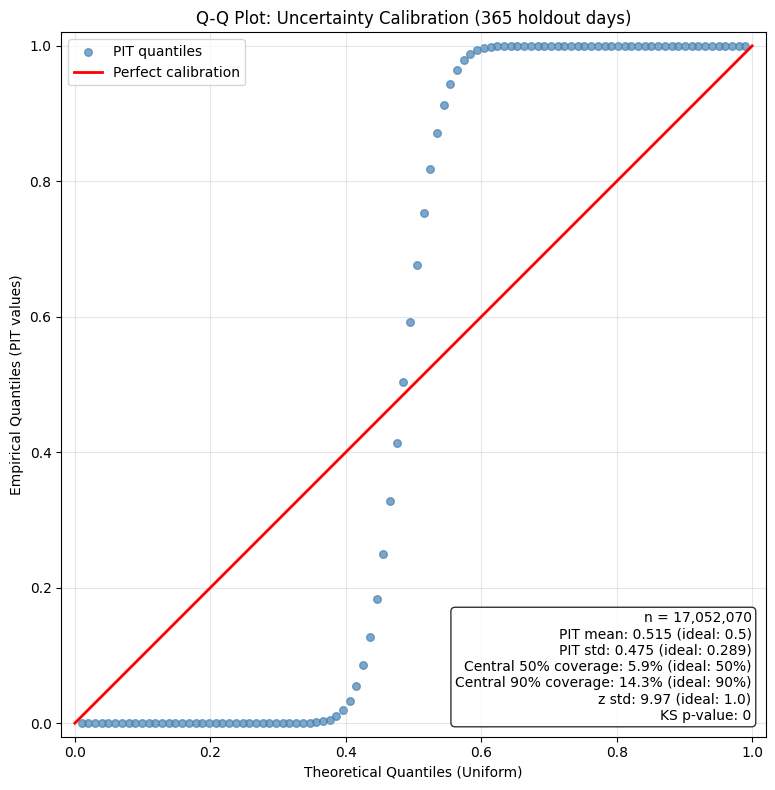


Calibration statistics:
  PIT mean: 0.515 (ideal: 0.5)
  PIT std:  0.475 (ideal: 0.289)
  z std:    9.97 (ideal: 1.0)
  50% coverage: 5.9% (ideal: 50%)
  90% coverage: 14.3% (ideal: 90%)
  KS test p-value: 0


In [15]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths_denorm,
    all_preds=all_preds_denorm,
    all_sigmas=all_sigmas,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/plots/reliability_diagram.png


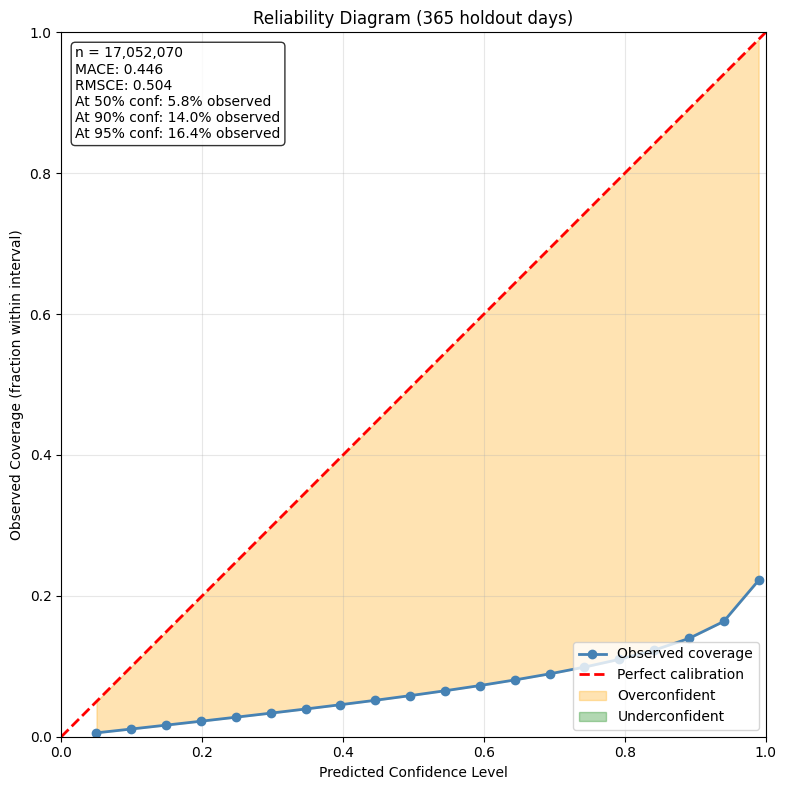


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.446
  At 50% confidence: 5.8% observed (ideal: 50%)
  At 90% confidence: 14.0% observed (ideal: 90%)
  At 95% confidence: 16.4% observed (ideal: 95%)


In [16]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths_denorm,
    all_preds=all_preds_denorm,
    all_sigmas=all_sigmas,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

In [17]:
import json

metrics_path = MODEL_DIR / 'metrics.json'

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "model_type": params.MODEL_TYPE,   # was: input_data, sparsity_type, sparsity_value
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
    },
    "overall": {
        "mae": float(np.nanmean(m.mae_grid)),
        "rmse": float(np.nanmean(m.rmse_grid)),
        "bias": float(np.nanmean(m.bias_grid)),
        "crps": float(m.overall_crps),
        "skill_score": float(m.global_skill),
    },
    "correlations": {
        "uncertainty_error": float(perpixel_corr),
        "altitude_error": float(alt_corr),
        "mtpi_error": float(mtpi_corr),
        "doy_error": float(doy_corr),
    },
    "calibration": {
        "pit_mean": float(calibration_stats["pit_mean"]),
        "pit_std": float(calibration_stats["pit_std"]),
        "z_std": float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value": float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace": float(reliability_stats["mace"]),
        "coverage_at_50": float(reliability_stats["coverage_at_50"]),
        "coverage_at_90": float(reliability_stats["coverage_at_90"]),
        "coverage_at_95": float(reliability_stats["coverage_at_95"]),
    },
}

metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/test-2023-30e-5f-smacnp-crps-2000sub-altcorrection/metrics.json


In [19]:
# Denormalize lat/lon back to degrees using ERA5 metadata bounds
lat_range = metadata.lat_max - metadata.lat_min
lon_range = metadata.lon_max - metadata.lon_min

# Target points (M,) — from x_target_static columns 0 and 1
target_lats = x_target_static[:, 0].cpu().numpy() * lat_range + metadata.lat_min
target_lons = x_target_static[:, 1].cpu().numpy() * lat_range + metadata.lon_min

# Context points (N,) — from x_context columns 0 and 1 (static, take first time step)
context_lats = x_context[0, :, 0].cpu().numpy() * lat_range + metadata.lat_min
context_lons = x_context[0, :, 1].cpu().numpy() * lon_range + metadata.lon_min


Zurich: target_point_idx=70299, matched (47.3873°N, 7.6434°E), 67.48 km away


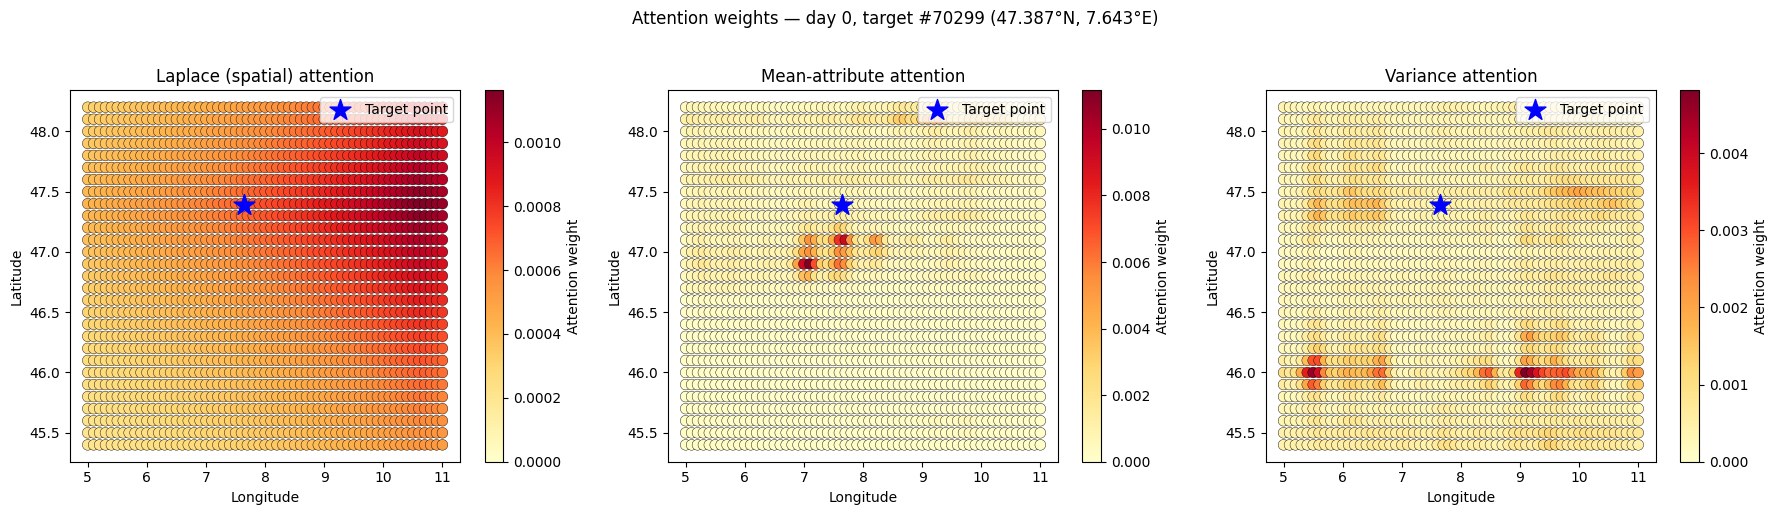

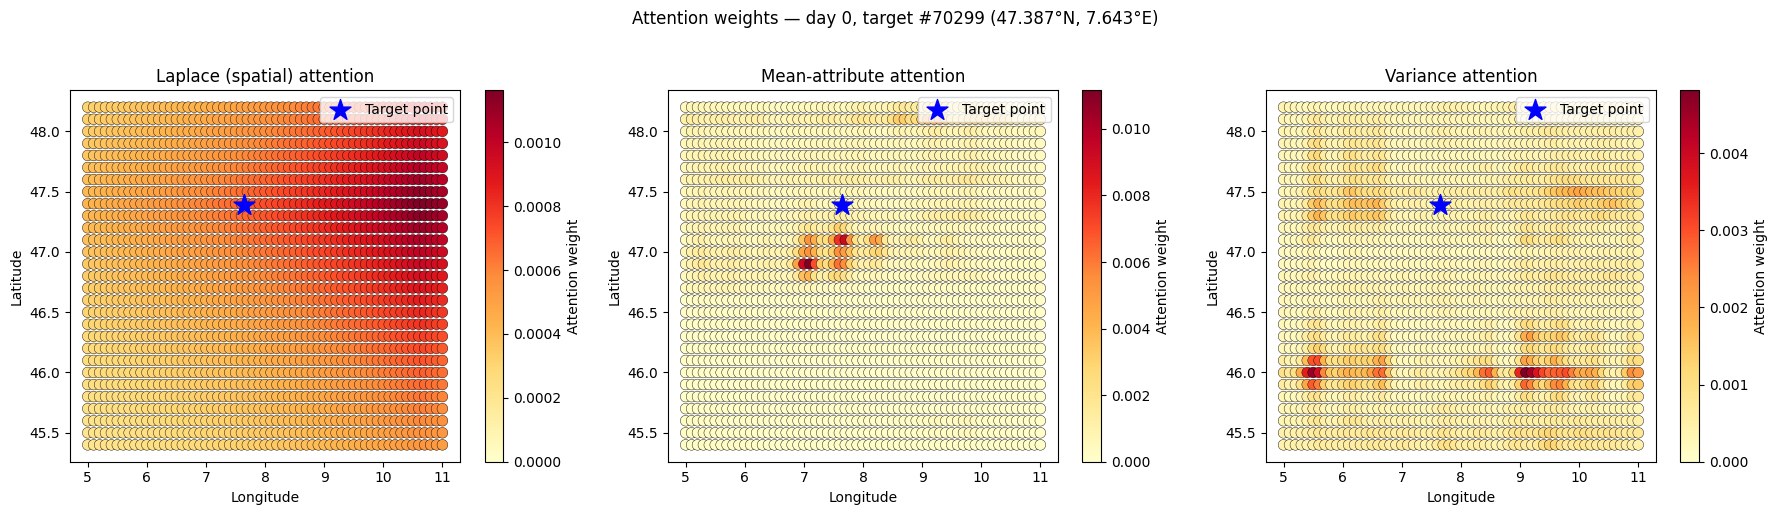

In [22]:
from visualization import find_target_point, plot_attention_maps

# Some predefined reference points for which attention can be visualized:
LOCATIONS = {
    'Zurich':   (47.376, 8.541),
    'Geneva':   (46.204, 6.143),
    'Neuchatel':(46.990, 6.929), 
    'Bern':     (46.948, 7.447),
    'Zermatt':  (46.020, 7.749),
    'Davos':    (46.803, 9.837),
    'Other':    (47.000, 7.000),
}

name = 'Zurich'  # Select the point for which the attention map should be displayed
lat, lon = LOCATIONS[name]
idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, target_lats, target_lons)
print(f"{name}: target_point_idx={idx}, matched ({matched_lat:.4f}°N, {matched_lon:.4f}°E), {dist_km:.2f} km away")

plot_attention_maps(
    model=model,
    x_context=x_context,
    y_context=y_context,
    x_target_static=x_target_static,
    day_idx=0,
    target_point_idx=idx,
    context_lats=context_lats,
    context_lons=context_lons,
    target_lats=target_lats,
    target_lons=target_lons,
    device=device,
)



## Summary

This notebook demonstrates how to:
1. Load trained convCNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Generate spatial predictions for the entire MeteoSwiss grid
4. **Per-fold:** Visualize a single representative day showing ERA5 input, ground truth, predictions, and bias
   The residual maps show where the model performs well (white) and where it struggles (blue=lower predictions, red=higher predictions).
5. **Combined across all folds:** Since holdout periods are non-overlapping, predictions from all folds are concatenated to produce a unified evaluation covering the entire year:
   - Per-pixel error maps (MAE, RMSE, bias)
   - Uncertainty calibration (predicted σ vs actual MAE)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to ERA5 bilinear interpolation baseline
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration - the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarizes miscalibration